In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Generate sample data - 3 clusters
def generate_data():
    # Cluster 1: centered at (2, 2)
    cluster1 = torch.randn(20, 2) * 0.5 + torch.tensor([2.0, 2.0])
    
    # Cluster 2: centered at (7, 3)
    cluster2 = torch.randn(20, 2) * 0.5 + torch.tensor([7.0, 3.0])
    
    # Cluster 3: centered at (5, 8)
    cluster3 = torch.randn(20, 2) * 0.5 + torch.tensor([5.0, 8.0])
    
    # Combine all clusters
    data = torch.cat([cluster1, cluster2, cluster3], dim=0)
    
    return data

# Generate data
X = generate_data()
print(f"Data shape: {X.shape}")
print(f"First 5 data points:\n{X[:5]}")

Data shape: torch.Size([60, 2])
First 5 data points:
tensor([[2.9635, 2.7436],
        [2.4504, 0.9472],
        [2.3392, 1.3827],
        [1.9785, 1.1977],
        [1.6239, 2.8244]])


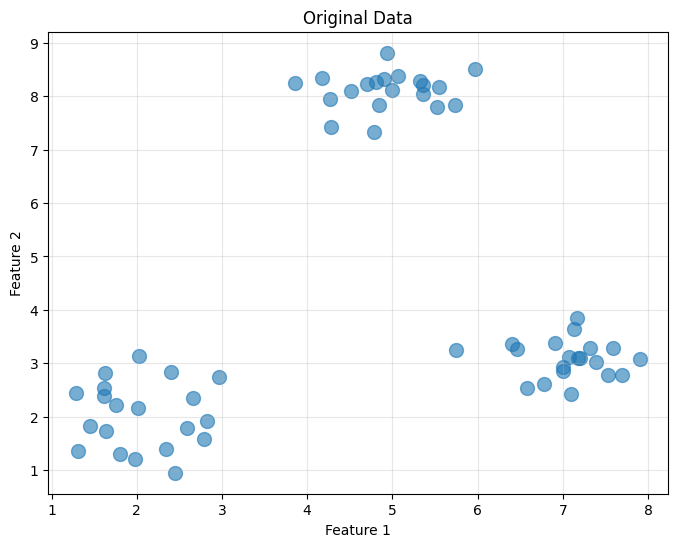

In [3]:
# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.6, s=100)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
class HierarchicalClustering:
    def __init__(self, n_clusters=3, linkage='average'):
        """
        Agglomerative Hierarchical Clustering from scratch
        
        Parameters:
        -----------
        n_clusters : int
            Number of clusters to form
        linkage : str
            Linkage criterion: 'single', 'complete', or 'average'
        """
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels = None
        self.history = []  # Store merge history for dendrogram
        
    def compute_distance(self, point1, point2):
        """
        Compute Euclidean distance between two points
        """
        return torch.sqrt(torch.sum((point1 - point2) ** 2))
    
    def compute_cluster_distance(self, cluster1_points, cluster2_points):
        """
        Compute distance between two clusters based on linkage method
        """
        if self.linkage == 'single':
            # Single linkage: minimum distance between any two points
            min_dist = float('inf')
            for p1 in cluster1_points:
                for p2 in cluster2_points:
                    dist = self.compute_distance(p1, p2)
                    if dist < min_dist:
                        min_dist = dist
            return min_dist
        
        elif self.linkage == 'complete':
            # Complete linkage: maximum distance between any two points
            max_dist = 0.0
            for p1 in cluster1_points:
                for p2 in cluster2_points:
                    dist = self.compute_distance(p1, p2)
                    if dist > max_dist:
                        max_dist = dist
            return max_dist
        
        elif self.linkage == 'average':
            # Average linkage: average distance between all pairs
            total_dist = 0.0
            count = 0
            for p1 in cluster1_points:
                for p2 in cluster2_points:
                    total_dist += self.compute_distance(p1, p2)
                    count += 1
            return total_dist / count if count > 0 else 0.0
        
        else:
            raise ValueError(f"Unknown linkage method: {self.linkage}")
    
    def fit(self, X):
        """
        Fit Hierarchical Clustering to data
        """
        n_samples = X.shape[0]
        
        # Initialize: each point is its own cluster
        # clusters is a dict mapping cluster_id -> list of point indices
        clusters = {i: [i] for i in range(n_samples)}
        cluster_points = {i: [X[i]] for i in range(n_samples)}
        
        print(f"Starting with {len(clusters)} clusters (each point is a cluster)")
        print(f"Target: {self.n_clusters} clusters\n")
        
        iteration = 0
        next_cluster_id = n_samples  # For new merged clusters
        
        # Continue merging until we reach desired number of clusters
        while len(clusters) > self.n_clusters:
            iteration += 1
            
            # Find the two closest clusters
            min_distance = float('inf')
            merge_pair = None
            
            cluster_ids = list(clusters.keys())
            for i in range(len(cluster_ids)):
                for j in range(i + 1, len(cluster_ids)):
                    c1_id = cluster_ids[i]
                    c2_id = cluster_ids[j]
                    
                    # Compute distance between clusters
                    dist = self.compute_cluster_distance(
                        cluster_points[c1_id], 
                        cluster_points[c2_id]
                    )
                    
                    if dist < min_distance:
                        min_distance = dist
                        merge_pair = (c1_id, c2_id)
            
            # Merge the two closest clusters
            c1_id, c2_id = merge_pair
            
            # Create new cluster by merging
            new_cluster_indices = clusters[c1_id] + clusters[c2_id]
            new_cluster_points = cluster_points[c1_id] + cluster_points[c2_id]
            
            # Store merge history
            self.history.append({
                'iteration': iteration,
                'merged': (c1_id, c2_id),
                'distance': min_distance.item(),
                'n_clusters': len(clusters) - 1
            })
            
            if iteration <= 5 or len(clusters) - 1 == self.n_clusters:
                print(f"Iteration {iteration}: Merged clusters {c1_id} and {c2_id} "
                      f"(distance: {min_distance:.4f}) -> {len(clusters) - 1} clusters remain")
            
            # Remove old clusters and add new one
            del clusters[c1_id]
            del clusters[c2_id]
            del cluster_points[c1_id]
            del cluster_points[c2_id]
            
            clusters[next_cluster_id] = new_cluster_indices
            cluster_points[next_cluster_id] = new_cluster_points
            next_cluster_id += 1
        
        print(f"\nFinal: {len(clusters)} clusters")
        
        # Create label array
        self.labels = torch.zeros(n_samples, dtype=torch.long)
        for cluster_label, (cluster_id, indices) in enumerate(clusters.items()):
            for idx in indices:
                self.labels[idx] = cluster_label
        
        return self
    
    def predict(self, X):
        """
        Return cluster labels
        """
        return self.labels

In [5]:
# Train with Average Linkage
print("=" * 60)
print("AVERAGE LINKAGE")
print("=" * 60)
hc_avg = HierarchicalClustering(n_clusters=3, linkage='average')
hc_avg.fit(X)
labels_avg = hc_avg.predict(X)

AVERAGE LINKAGE
Starting with 60 clusters (each point is a cluster)
Target: 3 clusters

Iteration 1: Merged clusters 22 and 37 (distance: 0.0188) -> 59 clusters remain
Iteration 2: Merged clusters 29 and 39 (distance: 0.0808) -> 58 clusters remain
Iteration 3: Merged clusters 47 and 51 (distance: 0.0885) -> 57 clusters remain
Iteration 4: Merged clusters 24 and 25 (distance: 0.1068) -> 56 clusters remain
Iteration 5: Merged clusters 41 and 43 (distance: 0.1081) -> 55 clusters remain
Iteration 57: Merged clusters 112 and 113 (distance: 1.2981) -> 3 clusters remain

Final: 3 clusters


In [6]:
# Train with Single Linkage
print("\n" + "=" * 60)
print("SINGLE LINKAGE")
print("=" * 60)
hc_single = HierarchicalClustering(n_clusters=3, linkage='single')
hc_single.fit(X)
labels_single = hc_single.predict(X)


SINGLE LINKAGE
Starting with 60 clusters (each point is a cluster)
Target: 3 clusters

Iteration 1: Merged clusters 22 and 37 (distance: 0.0188) -> 59 clusters remain
Iteration 2: Merged clusters 29 and 39 (distance: 0.0808) -> 58 clusters remain
Iteration 3: Merged clusters 47 and 51 (distance: 0.0885) -> 57 clusters remain
Iteration 4: Merged clusters 24 and 25 (distance: 0.1068) -> 56 clusters remain
Iteration 5: Merged clusters 41 and 43 (distance: 0.1081) -> 55 clusters remain
Iteration 57: Merged clusters 32 and 106 (distance: 0.6627) -> 3 clusters remain

Final: 3 clusters


In [7]:
# Train with Complete Linkage
print("\n" + "=" * 60)
print("COMPLETE LINKAGE")
print("=" * 60)
hc_complete = HierarchicalClustering(n_clusters=3, linkage='complete')
hc_complete.fit(X)
labels_complete = hc_complete.predict(X)


COMPLETE LINKAGE
Starting with 60 clusters (each point is a cluster)
Target: 3 clusters

Iteration 1: Merged clusters 22 and 37 (distance: 0.0188) -> 59 clusters remain
Iteration 2: Merged clusters 29 and 39 (distance: 0.0808) -> 58 clusters remain
Iteration 3: Merged clusters 47 and 51 (distance: 0.0885) -> 57 clusters remain
Iteration 4: Merged clusters 24 and 25 (distance: 0.1068) -> 56 clusters remain
Iteration 5: Merged clusters 41 and 43 (distance: 0.1081) -> 55 clusters remain
Iteration 57: Merged clusters 106 and 113 (distance: 2.2271) -> 3 clusters remain

Final: 3 clusters


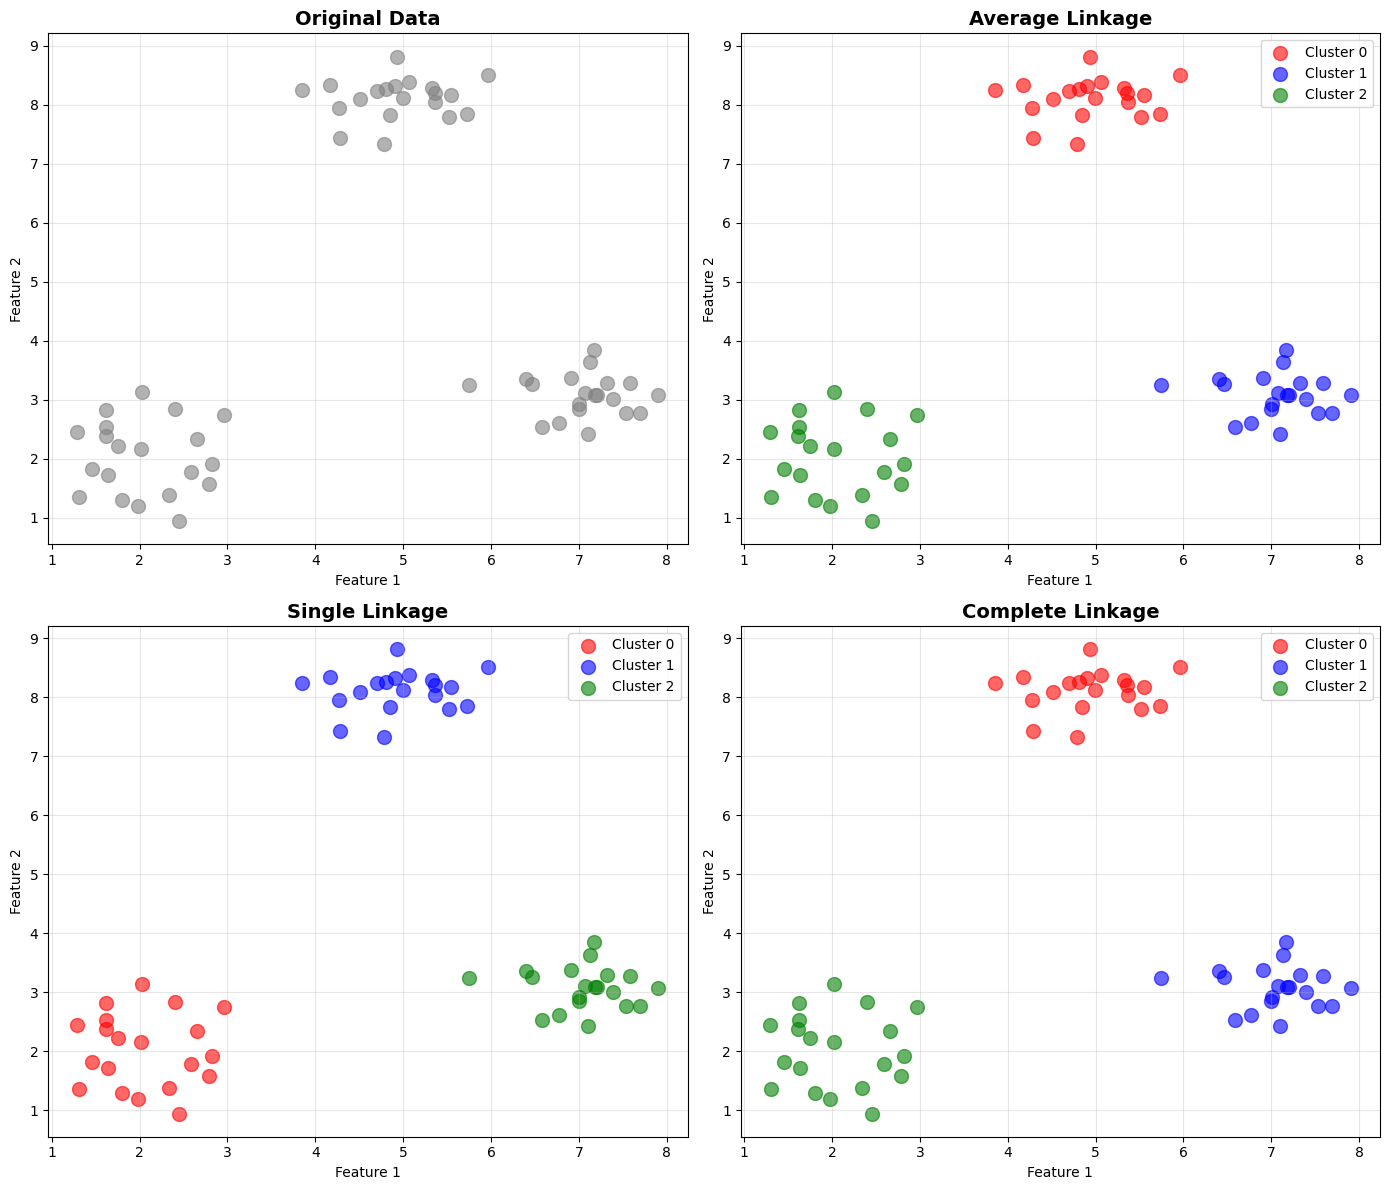

In [8]:
# Visualize clustering results for all linkage methods
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = ['red', 'blue', 'green', 'orange', 'purple']

# Original data
axes[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.6, c='gray', s=100)
axes[0, 0].set_title('Original Data', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].grid(True, alpha=0.3)

# Average Linkage
for i in range(hc_avg.n_clusters):
    cluster_points = X[labels_avg == i]
    axes[0, 1].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100)
axes[0, 1].set_title('Average Linkage', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Single Linkage
for i in range(hc_single.n_clusters):
    cluster_points = X[labels_single == i]
    axes[1, 0].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100)
axes[1, 0].set_title('Single Linkage', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Complete Linkage
for i in range(hc_complete.n_clusters):
    cluster_points = X[labels_complete == i]
    axes[1, 1].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6, s=100)
axes[1, 1].set_title('Complete Linkage', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
print("=" * 60)
print("SIMPLE EXAMPLE: 4 Points, 2 Clusters")
print("=" * 60)

# Create 4 simple data points
simple_data = torch.tensor([
    [1.0, 1.0],
    [1.5, 2.0],
    [5.0, 8.0],
    [8.0, 8.0]
])

print(f"\nData points:")
for i, point in enumerate(simple_data):
    print(f"  P{i+1}: {point.tolist()}")

print("\n" + "-" * 60)
print("Computing pairwise distances:")
print("-" * 60)

# Show pairwise distances
for i in range(len(simple_data)):
    for j in range(i + 1, len(simple_data)):
        dist = torch.sqrt(torch.sum((simple_data[i] - simple_data[j]) ** 2))
        print(f"Distance P{i+1} to P{j+1}: {dist:.4f}")

print()

SIMPLE EXAMPLE: 4 Points, 2 Clusters

Data points:
  P1: [1.0, 1.0]
  P2: [1.5, 2.0]
  P3: [5.0, 8.0]
  P4: [8.0, 8.0]

------------------------------------------------------------
Computing pairwise distances:
------------------------------------------------------------
Distance P1 to P2: 1.1180
Distance P1 to P3: 8.0623
Distance P1 to P4: 9.8995
Distance P2 to P3: 6.9462
Distance P2 to P4: 8.8459
Distance P3 to P4: 3.0000



In [10]:
# Apply Hierarchical Clustering with 2 clusters (Average Linkage)
print("\n" + "=" * 60)
print("APPLYING HIERARCHICAL CLUSTERING (Average Linkage)")
print("=" * 60 + "\n")

hc_simple = HierarchicalClustering(n_clusters=2, linkage='average')
hc_simple.fit(simple_data)
simple_labels = hc_simple.predict(simple_data)

print(f"\nFinal cluster assignments: {simple_labels.tolist()}")
for i, label in enumerate(simple_labels):
    print(f"  P{i+1} -> Cluster {label.item()}")


APPLYING HIERARCHICAL CLUSTERING (Average Linkage)

Starting with 4 clusters (each point is a cluster)
Target: 2 clusters

Iteration 1: Merged clusters 0 and 1 (distance: 1.1180) -> 3 clusters remain
Iteration 2: Merged clusters 2 and 3 (distance: 3.0000) -> 2 clusters remain

Final: 2 clusters

Final cluster assignments: [0, 0, 1, 1]
  P1 -> Cluster 0
  P2 -> Cluster 0
  P3 -> Cluster 1
  P4 -> Cluster 1


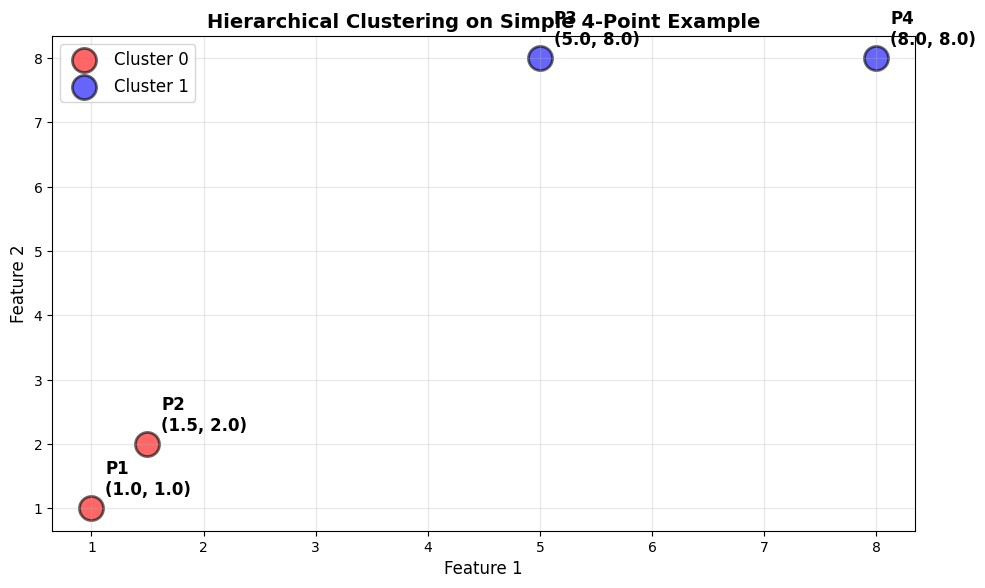

In [11]:
# Visualize simple example
plt.figure(figsize=(10, 6))

colors_simple = ['red', 'blue', 'green']
for i in range(2):
    cluster_points = simple_data[simple_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors_simple[i], s=300, label=f'Cluster {i}', 
                alpha=0.6, edgecolors='black', linewidths=2)

# Annotate points
for i, point in enumerate(simple_data):
    plt.annotate(f'P{i+1}\n({point[0]:.1f}, {point[1]:.1f})', 
                xy=point, xytext=(10, 10), textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Hierarchical Clustering on Simple 4-Point Example', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Display merge history
print("\nMerge History (showing first 10 merges):")
print("=" * 70)
for merge in hc_avg.history[:10]:
    print(f"Iteration {merge['iteration']:2d}: Merged {merge['merged']} | "
          f"Distance: {merge['distance']:.4f} | Clusters left: {merge['n_clusters']}")


Merge History (showing first 10 merges):
Iteration  1: Merged (22, 37) | Distance: 0.0188 | Clusters left: 59
Iteration  2: Merged (29, 39) | Distance: 0.0808 | Clusters left: 58
Iteration  3: Merged (47, 51) | Distance: 0.0885 | Clusters left: 57
Iteration  4: Merged (24, 25) | Distance: 0.1068 | Clusters left: 56
Iteration  5: Merged (41, 43) | Distance: 0.1081 | Clusters left: 55
Iteration  6: Merged (28, 60) | Distance: 0.1234 | Clusters left: 54
Iteration  7: Merged (7, 10) | Distance: 0.1580 | Clusters left: 53
Iteration  8: Merged (23, 35) | Distance: 0.1591 | Clusters left: 52
Iteration  9: Merged (55, 64) | Distance: 0.1686 | Clusters left: 51
Iteration 10: Merged (3, 5) | Distance: 0.2016 | Clusters left: 50


Starting with 60 clusters (each point is a cluster)
Target: 2 clusters

Iteration 1: Merged clusters 22 and 37 (distance: 0.0188) -> 59 clusters remain
Iteration 2: Merged clusters 29 and 39 (distance: 0.0808) -> 58 clusters remain
Iteration 3: Merged clusters 47 and 51 (distance: 0.0885) -> 57 clusters remain
Iteration 4: Merged clusters 24 and 25 (distance: 0.1068) -> 56 clusters remain
Iteration 5: Merged clusters 41 and 43 (distance: 0.1081) -> 55 clusters remain
Iteration 58: Merged clusters 115 and 116 (distance: 5.1597) -> 2 clusters remain

Final: 2 clusters
Starting with 60 clusters (each point is a cluster)
Target: 3 clusters

Iteration 1: Merged clusters 22 and 37 (distance: 0.0188) -> 59 clusters remain
Iteration 2: Merged clusters 29 and 39 (distance: 0.0808) -> 58 clusters remain
Iteration 3: Merged clusters 47 and 51 (distance: 0.0885) -> 57 clusters remain
Iteration 4: Merged clusters 24 and 25 (distance: 0.1068) -> 56 clusters remain
Iteration 5: Merged clusters 41 and

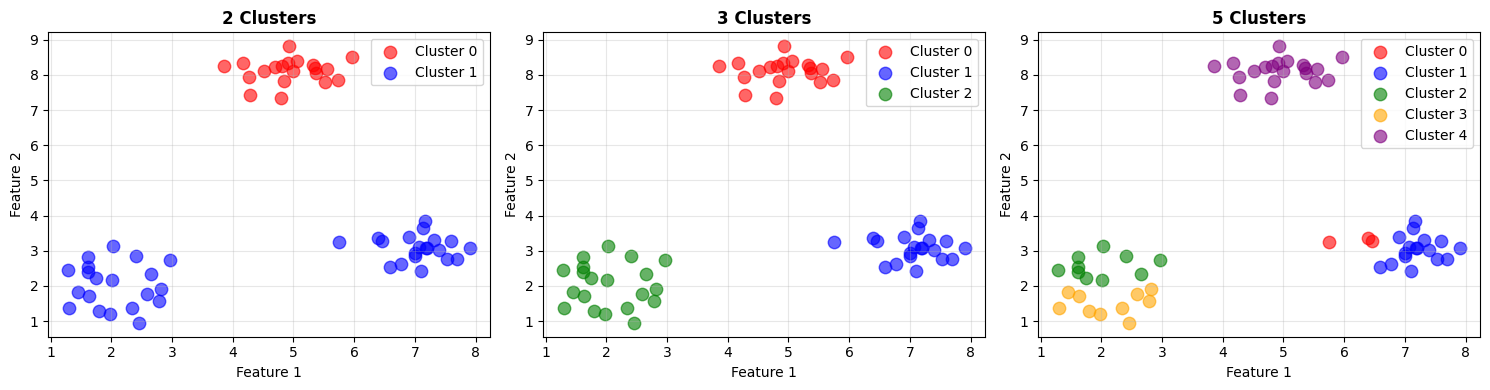

In [13]:
# Try different numbers of clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, n_clust in enumerate([2, 3, 5]):
    hc_temp = HierarchicalClustering(n_clusters=n_clust, linkage='average')
    hc_temp.fit(X)
    labels_temp = hc_temp.predict(X)
    
    for i in range(n_clust):
        cluster_points = X[labels_temp == i]
        axes[idx].scatter(cluster_points[:, 0], cluster_points[:, 1], 
                         c=colors[i % len(colors)], label=f'Cluster {i}', 
                         alpha=0.6, s=80)
    
    axes[idx].set_title(f'{n_clust} Clusters', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()